# Group 42

Main

A* path length = 37
[(40, 10), (39, 11), (38, 12), (37, 13), (36, 14), (35, 15), (34, 16), (33, 17), (32, 18), (31, 19), (30, 20), (29, 21), (28, 22), (27, 23), (26, 24), (26, 25), (25, 26), (24, 27), (23, 28), (22, 29), (22, 30), (21, 31), (20, 31), (19, 31), (18, 32), (17, 33), (16, 34), (15, 35), (14, 36), (13, 37), (12, 38), (11, 39), (10, 39), (9, 39), (8, 39), (7, 39), (6, 39), (5, 40)]


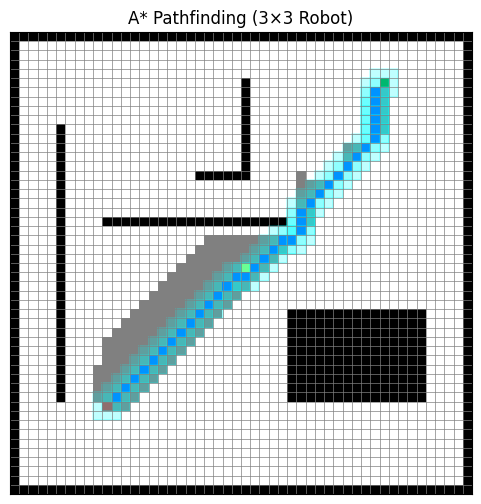

In [1]:

import matplotlib.pyplot as plt
import numpy as np
import cv2
import time
import asyncio

from thymio import Thymio

import vision
import motion_controll
import filtering
import local_nav
import global_nav

In [2]:
thymio = Thymio(pos_init=[0, 0], orient=0)
await thymio._connect_to_thymio_()

Thymio connected


In [11]:
await thymio.unlock()

Thymio unlocked


In [8]:
await thymio.update_ir()
print(thymio.ir_sensors[0:5])

[0, 1593, 0, 1353, 1532]


In [3]:
thymio.set_motor_speeds([100, 100])

In [4]:
thymio.stop()

In [3]:
thymio.set_motor_speeds([100, 100])
while True:
    await thymio.update_ir()
    if sum(thymio.ir_sensors) > 2000:
        thymio.stop()
        break
    

Next cell makes the Thymio robot move forward for 4 seconds and then stops each time the Forward button is pressed. Program stops when the Backward button is pressed.  
It is intended to collect data for computing the **velocity variance**.

In [13]:
await thymio.button_loop()

Forward pressed
Forward pressed
Forward pressed
Forward pressed
Forward pressed
Forward pressed
Forward pressed
Forward pressed
Forward pressed
Forward pressed
Forward pressed
Forward pressed
Forward pressed
Forward pressed
Forward pressed
Forward pressed
Forward pressed
Forward pressed
Backward pressed


Using this program to measure (with a ruler) the distance travelled by the bot each time to see differencies despite constant time and compute the variance on speed state.

In [17]:
data_velocity_error=[142, 138, 138, 137, 139, 137, 138, 135, 142, 141] #distances in mm travelled at presumed same speed for a constant time
data_velocity_error=[x/thymio.DELTA_T for x in data_velocity_error] #distances divided by the constant time to get true velocities

mean_speed=np.mean(data_velocity_error) #mean speed in mm/s
print(mean_speed)
ratio_speed=100/mean_speed #from tests above, for a speed of 100 we get a mean speed of 34.675 mm/s

q_v = np.var(data_velocity_error) # variance on speed state
print(q_v)

34.675
0.300625


<img src="position_measurement.png" width="400">

From the camera we got a data set of XY position measurements from the same position to search for some differencies and compute variances on XY states and measurements.

In [ ]:
measurements_from_camera=np.array([[13.118, 13.303], [13.153, 13.317], [13.090, 13.307], [13.062, 13.255], [13.059, 13.281],
                                   [13.074, 13.321], [13.026, 13.273], [13.073, 13.295], [13.023, 13.270]])
x_measurements = [x[0] for x in measurements_from_camera]
y_measurements = [y[1] for y in measurements_from_camera]

var_x = np.var(x_measurements)
var_y = np.var(y_measurements)
print("x measurement variance is: ", var_x)
print("y measurement variance is: ", var_y)

q_x = var_x/2 #variance on x position state
r_x = var_x/2 #variance on x position measurement
q_y = var_y/2 #variance on y position state
r_y = var_y/2 #variance on y position measurement

x measurement variance is:  0.0015213333333333543
y measurement variance is:  0.00046133333333333155


In [6]:
# -------------------------------------------
#        HOMOGRAPHY + GLOBAL MAPPING
# -------------------------------------------

def computeHomography(arena_corners_pixels, arena_width_m, arena_height_m):
    """
    arena_corners_pixels: list of 4 (u,v) pixel points in the order:
        bottom-left, bottom-right, top-right, top-left
    arena_width_m: real arena width in meters
    arena_height_m: real arena height in meters
    """

    # Real-world coordinates of the arena corners (meters)
    world_corners = np.array([
        [0, 0],                          # Bottom-left
        [arena_width_m, 0],              # Bottom-right
        [arena_width_m, arena_height_m], # Top-right
        [0, arena_height_m]              # Top-left
    ], dtype=float)

    img_pts = np.array(arena_corners_pixels, dtype=float)
    world_pts = world_corners.reshape(-1, 1, 2)

    H, _ = cv2.findHomography(img_pts, world_pts)
    return H


def pixelToGlobal(H, pixel_point):
    """
    Convert a pixel point (u,v) into global (X,Y) using homography H.
    """
    u, v = pixel_point
    pt = np.array([u, v, 1.0])
    world = H @ pt
    world /= world[2]  # Normalize

    X = float(world[0])
    Y = float(world[1])

    return X, Y


def getGlobalLocation(arena_corners_pixels, arena_width_m, arena_height_m,
                      marker_cam_x, marker_cam_y):

    H = computeHomography(arena_corners_pixels, arena_width_m, arena_height_m)
    return pixelToGlobal(H, (marker_cam_x, marker_cam_y))


# -------------------------------------------
#        ARENA CORNER DETECTION
# -------------------------------------------

def getArenaCornerPixels(image):
    """
    Finds 4 red arena corner markers using HSV red thresholding.
    Returns (bl, br, tr, tl) in pixel coordinate order.
    """

    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Red thresholds
    lower_red1 = np.array([0, 120, 70])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([170, 120, 70])
    upper_red2 = np.array([180, 255, 255])

    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask = mask1 | mask2
    mask = cv2.medianBlur(mask, 5)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    red_centers = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > 100:  # ignore small noise
            x, y, w, h = cv2.boundingRect(cnt)
            cx = x + w // 2
            cy = y + h // 2
            red_centers.append((cx, cy))

    if len(red_centers) != 4:
        print(f"Expected 4 arena corners, but found {len(red_centers)}")
        return [0, 0, 0, 0]

    # Sort into TL, TR, BL, BR structure
    red_centers = sorted(red_centers, key=lambda c: (c[1], c[0]))  # sort by row, then column
    top = sorted(red_centers[:2], key=lambda c: c[0])
    bottom = sorted(red_centers[2:], key=lambda c: c[0])

    tl, tr = top
    bl, br = bottom

    # Return in required order: bl, br, tr, tl
    return [bl, br, tr, tl]


# -------------------------------------------
#        ARUCO MARKER DETECTION
# -------------------------------------------

def getArucoLocationCameraFrame(cameraOrigin, image):
    """
    Detects first ArUco marker and returns:
    - center pixel (cx, cy)
    - heading angle in radians
    - 4 corner points
    """

    aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_5X5_50)
    parameters = cv2.aruco.DetectorParameters()
    detector = cv2.aruco.ArucoDetector(aruco_dict, parameters)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    corners, ids, _ = detector.detectMarkers(gray)

    if ids is None:
        return 0, 0, 0, None

    # Use first marker
    c = corners[0][0]  # shape (4,2)
    # Corner order: TL, TR, BR, BL in OpenCV ArUco
    tl, tr, br, bl = c

    # Compute center
    cx = int(c[:, 0].mean())
    cy = int(c[:, 1].mean())

    # Compute heading direction vector: TR - TL
    dir_vec = tr - tl
    heading_angle = np.arctan2(dir_vec[1], dir_vec[0])  # radians

    return cx, cy, heading_angle, c


def fastLocateRobot(frame, arena_width_m, arena_height_m):
    arena_corners = getArenaCornerPixels(frame)
    if arena_corners == [0,0,0,0]:
        return None
    cx, cy, heading, corners = getArucoLocationCameraFrame(arena_corners[0], frame)
    if corners is None:
        return None
    #X, Y = getGlobalLocation(arena_corners, arena_width_m, arena_height_m, cx, cy)
    heading_deg = np.degrees(heading) * -1
    return heading_deg

In [9]:

cap = cv2.VideoCapture(0)
ret, frame = cap.read()
start_theta= fastLocateRobot(frame, 26, 26)

thymio.set_motor_speeds([0,0])
delta_t = 2
start_time=0
k=1
data_theta_pos=np.zeros(k)
data_theta_neg=np.zeros(k)

for i in range(k):

    thymio.set_motor_speeds([100,-100])
    start_time=time.time()
    while time.time() - start_time < delta_t:
        await asyncio.sleep(0.01)
    thymio.set_motor_speeds([0, 0])
    ret, frame = cap.read()
    on_going_theta=fastLocateRobot(frame, 26,26)
    while on_going_theta is None:
        ret, frame = cap.read()
        on_going_theta = fastLocateRobot(frame, 26, 26)
    data_theta_pos[i]=on_going_theta-start_theta

    start_theta=on_going_theta
    thymio.set_motor_speeds([-100,100])
    start_time=time.time()
    while time.time() - start_time < delta_t:
        await asyncio.sleep(0.01)
    thymio.set_motor_speeds([0, 0])
    ret, frame = cap.read()
    on_going_theta=fastLocateRobot(frame, 26,26)
    while on_going_theta is None:
        ret, frame = cap.read()
        on_going_theta = fastLocateRobot(frame, 26, 26)
    data_theta_neg[i]=on_going_theta-start_theta

print(data_theta_pos)
print(data_theta_neg)

    

Expected 4 arena corners, but found 1
Expected 4 arena corners, but found 1
Expected 4 arena corners, but found 1
Expected 4 arena corners, but found 1
Expected 4 arena corners, but found 1
Expected 4 arena corners, but found 1
Expected 4 arena corners, but found 1
Expected 4 arena corners, but found 1
Expected 4 arena corners, but found 1
Expected 4 arena corners, but found 1
Expected 4 arena corners, but found 1
Expected 4 arena corners, but found 1
Expected 4 arena corners, but found 1
Expected 4 arena corners, but found 1
Expected 4 arena corners, but found 1
Expected 4 arena corners, but found 1
Expected 4 arena corners, but found 1
Expected 4 arena corners, but found 1
Expected 4 arena corners, but found 2
Expected 4 arena corners, but found 2
Expected 4 arena corners, but found 3
Expected 4 arena corners, but found 3
Expected 4 arena corners, but found 3
Expected 4 arena corners, but found 3
Expected 4 arena corners, but found 3
Expected 4 arena corners, but found 5
Expected 4 a

TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'

Exception in thread Thread-4:
Traceback (most recent call last):
  File "/Users/eleonore/miniconda3/envs/mpc2025/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/Users/eleonore/miniconda3/envs/mpc2025/lib/python3.12/site-packages/tdmclient/tcp.py", line 73, in run
    packet = self.read_packet()
             ^^^^^^^^^^^^^^^^^^
  File "/Users/eleonore/miniconda3/envs/mpc2025/lib/python3.12/site-packages/tdmclient/tcp.py", line 66, in read_packet
    raise error
  File "/Users/eleonore/miniconda3/envs/mpc2025/lib/python3.12/site-packages/tdmclient/tcp.py", line 59, in read_packet
    packet_len = self.read_uint32()
                 ^^^^^^^^^^^^^^^^^^
  File "/Users/eleonore/miniconda3/envs/mpc2025/lib/python3.12/site-packages/tdmclient/tcp.py", line 46, in read_uint32
    b = self.io.read(4)
        ^^^^^^^^^^^^^^^
  File "/Users/eleonore/miniconda3/envs/mpc2025/lib/python3.12/site-packages/tdmclient/tcp.py", line 99, in read
    return self.socket.rec